In [ ]:
# Bias Detection in Model
# Focus on 3 models
# 1. Logistic Regression
# 2. Random Forest
# 3. Neural Network

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import accuracy_score, roc_auc_score, ConfusionMatrixDisplay, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [19]:
# Load and preprocess data
df = pd.read_csv('../../datasets/recruitement.csv')

# data information
print(df.head())
print(df.shape)

# Clean dataset


# Encoding categorical variables
df['Age_Group'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 65], labels=['18-25', '26-35', '36-45', '46-55', '56-65'])

df['Selected'] = df['Selected'].map({'Yes': 1, 'No': 0})

df.drop(columns=['Candidate_ID', 'Age'], inplace=True)

mlb = MultiLabelBinarizer()
skills_df = df.copy()

skills_df['Skills'] = skills_df['Skills'].fillna('').str.lower().str.split(',')

skills_encoded = pd.DataFrame(mlb.fit_transform(skills_df['Skills']),
                              columns=[f"skill_{s.replace(' ', '_')}" for s in mlb.classes_])

skills_df = pd.concat([df.drop(columns=['Skills']), skills_encoded], axis=1)

categorical_cols = ['Gender', 'Race', 'Education', 'Age_Group', "Certifications"]


df_encoded = skills_df.copy()

for col in categorical_cols:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

skills_cols = [col for col in df_encoded.columns if col.startswith('skill_')]

skills_cols = [col for col in df_encoded.columns if col.startswith('skill_')]
numerical_cols = ["Experience_Years", "Screening_Score", "Selected"]

df_encoded = df_encoded[categorical_cols + numerical_cols + skills_cols]

  Candidate_ID      Gender   Race  Age    Education  Experience_Years  \
0        C0001        Male  Asian   23  High School                 0   
1        C0002  Non-binary  Asian   32     Bachelor                13   
2        C0003      Female  White   31     Bachelor                11   
3        C0004      Female  Asian   35  High School                12   
4        C0005        Male  Black   25     Bachelor                 2   

    Job_Role_Applied                                          Skills  \
0  Software Engineer                                Git, Python, AWS   
1    Sales Executive                  Cold Calling, CRM, Negotiation   
2  Software Engineer                               Java, Python, AWS   
3    Project Manager                    Scheduling, Budgeting, Agile   
4         HR Manager  Communication, Conflict Resolution, Leadership   

  Certifications  Screening_Score Selected  
0            NaN             69.0       No  
1            AWS             78.4     

In [20]:
# Prepare features and target
X = df_encoded.drop(columns=['Selected'])  # drop non-feature columns
y = df_encoded['Selected']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Performance Metrics 
# accuracy, ROC-AUC, Recall, Precision, F1-Score
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None


    print(classification_report(y_test, y_pred, target_names = ["Yes", "No"]))

    return {
        'accuracy': accuracy,
        'roc_auc': roc_auc
    }

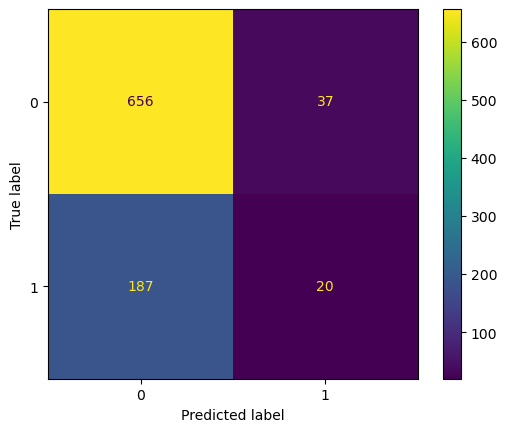

              precision    recall  f1-score   support

         Yes       0.78      0.95      0.85       693
          No       0.35      0.10      0.15       207

    accuracy                           0.75       900
   macro avg       0.56      0.52      0.50       900
weighted avg       0.68      0.75      0.69       900

Logistic Regression Performance: {'accuracy': 0.7511111111111111, 'roc_auc': 0.6997371924908156}


In [34]:
# Logistic Regression
logistic_regression_model = LogisticRegression(max_iter=1000)
logistic_regression_model.fit(X_train, y_train)

print("Logistic Regression Performance:", evaluate_model(logistic_regression_model, X_test, y_test))

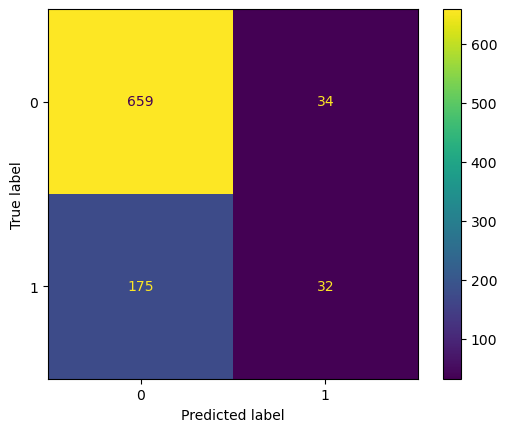

              precision    recall  f1-score   support

         Yes       0.79      0.95      0.86       693
          No       0.48      0.15      0.23       207

    accuracy                           0.77       900
   macro avg       0.64      0.55      0.55       900
weighted avg       0.72      0.77      0.72       900

Random Forest Performance: {'accuracy': 0.7677777777777778, 'roc_auc': 0.6927069173445985}


In [35]:
# Random Forest
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

print("Random Forest Performance:", evaluate_model(random_forest_model, X_test, y_test))

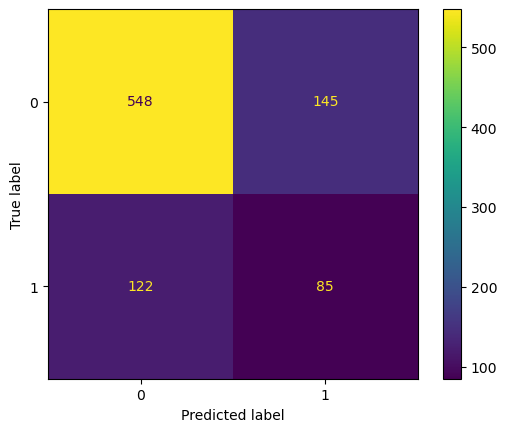

              precision    recall  f1-score   support

         Yes       0.82      0.79      0.80       693
          No       0.37      0.41      0.39       207

    accuracy                           0.70       900
   macro avg       0.59      0.60      0.60       900
weighted avg       0.71      0.70      0.71       900

Neural Network Performance: {'accuracy': 0.7033333333333334, 'roc_auc': 0.6485768659681703}


In [36]:
# Neural Network
neural_network_model = MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42)
neural_network_model.fit(X_train, y_train)

print("Neural Network Performance:", evaluate_model(neural_network_model, X_test, y_test))